In [19]:
import os
import json
from collections import defaultdict
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

import sympy
import numpy as np

from experiments.feynman_dm import FeynmanDataModule, TransformedFeynmanDataModule
from scipy.stats import kendalltau
from sklearn.metrics import mean_absolute_percentage_error

In [17]:
# colors = [(51, 94, 150), (76, 124, 49), (178, 86, 40)]

# colors = np.array(colors) / 255

colors = [
    'blue',
    'red'
]

# colors = plt.rcParams['axes.color_cycle']

In [13]:
pi = np.pi
cos = np.cos
sin = np.sin
sqrt = np.sqrt
exp = np.exp
arcsin = np.arcsin
arccos = np.arccos
log = np.log
ln = np.log
tanh = np.tanh
asin = np.arcsin
acos = np.arccos
cosh = np.cosh
atan = np.arctan
acosh = np.arccosh

def evaluate_expression(expression, symbols, input_values):
    '''
    Args:
        expression (str): equation in str format
        symbols (list): names of input variables
        input_values (ndarray): a numpy array whose shape is (num data point x num input variables)
    '''
    expression = expression.replace("^", "**")
    exp_as_func = eval(f"lambda {','.join(symbols)}: {expression}")

    X_temp = input_values
    # Y = []

    # for i in range(len(X_temp)):
    #     Y.append(exp_as_func(*list(X_temp[i])))
    # Y = np.array(Y)
    Y = exp_as_func(*[X_temp[:, i] for i in range(X_temp.shape[1])])

    return Y

In [16]:
dm = FeynmanDataModule()
dm.setup()

transformed_dm = TransformedFeynmanDataModule()
transformed_dm.setup()

Fetching 104 files:   0%|          | 0/104 [00:00<?, ?it/s]

Fetching 473 files:   0%|          | 0/473 [00:00<?, ?it/s]

In [4]:
run_dirs = {r.stem.split("_")[-1]: r for r in Path("lasr_runs/exp_0.bk").glob("*/run_logs_*.csv")}
transformed_run_dirs = {os.path.basename(r.parent): r for r in Path("lasr_runs/exp_1.bk").glob("*/run_logs_*.csv")}

# run_dirs = {r.stem.split("_")[-1]: r for r in Path("lasr_runs/exp_30").glob("*/run_logs_*.csv")}
# transformed_run_dirs = {os.path.basename(r.parent): r for r in Path("lasr_runs/exp_1.bk").glob("*/run_logs_*.csv")}

In [5]:
grouped_run_dirs = defaultdict(list)

for k,v in run_dirs.items():
    grouped_run_dirs[k].append(v)

for k,v in transformed_run_dirs.items():
    grouped_run_dirs[k.split('_')[0]].append(v)

In [6]:
grouped_run_dirs

defaultdict(list,
            {'I.6.2b': [PosixPath('lasr_runs/exp_50/I.6.2b/run_logs_I.6.2b.csv')],
             'I.6.2a': [PosixPath('lasr_runs/exp_50/I.6.2a/run_logs_I.6.2a.csv'),
              PosixPath('lasr_runs/exp_51/I.6.2a_0_0/run_logs_I.6.2a_0_0.csv')],
             'I.6.2': [PosixPath('lasr_runs/exp_50/I.6.2/run_logs_I.6.2.csv')]})

In [7]:
def compute_metrics(expression, data):
    X, y = data[:, 1:], data[:, 0]
    symbols = ['x' + str(i) for i in range(X.shape[1])]
    # print(expression, X.shape, symbols)

    y_pred = evaluate_expression(expression, symbols, X)

    nonnan_idx = np.argwhere(~np.isnan(y_pred))
    y_pred = y_pred[nonnan_idx]
    y = y[nonnan_idx]

    var = np.var(y)
    nmse = np.mean((y - y_pred)**2) / var 
    if np.sum((y - y.mean())**2) == 0:
        print(y)
    r2 = 1 - (np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2))
    kdt = kendalltau(y, y_pred)[0]
    mape = mean_absolute_percentage_error(y, y_pred)

    return {
        "mse": np.mean((y - y_pred)**2),
        "nmse": nmse,
        "r2": r2,
        "kdt": kdt,
        "mape": mape,
        "num_valid_points": len(y_pred),
    }

SUB = str.maketrans("₀₁₂₃₄₅₆₇₈₉","0123456789")
# print(dm.problems[dm.name2id[eq_name]])
# compute_metrics(dfs[0].iloc[0].Expression.strip().translate(SUB), dm.problems[dm.name2id[eq_name]].samples['train'])

In [8]:
grouped_run_dirs

defaultdict(list,
            {'I.37.4': [PosixPath('lasr_runs/exp_0.bk/I.37.4/run_logs_I.37.4.csv')],
             'II.6.15a': [PosixPath('lasr_runs/exp_0.bk/II.6.15a/run_logs_II.6.15a.csv')],
             'II.38.14': [PosixPath('lasr_runs/exp_0.bk/II.38.14/run_logs_II.38.14.csv')],
             'I.47.23': [PosixPath('lasr_runs/exp_0.bk/I.47.23/run_logs_I.47.23.csv')],
             'I.15.1': [PosixPath('lasr_runs/exp_0.bk/I.15.1/run_logs_I.15.1.csv')],
             'II.27.18': [PosixPath('lasr_runs/exp_0.bk/II.27.18/run_logs_II.27.18.csv')],
             'III.10.19': [PosixPath('lasr_runs/exp_0.bk/III.10.19/run_logs_III.10.19.csv')],
             'I.12.2': [PosixPath('lasr_runs/exp_0.bk/I.12.2/run_logs_I.12.2.csv'),
              PosixPath('lasr_runs/exp_1.bk/I.12.2_3_0/run_logs_I.12.2_3_0.csv'),
              PosixPath('lasr_runs/exp_1.bk/I.12.2_3_1/run_logs_I.12.2_3_1.csv'),
              PosixPath('lasr_runs/exp_1.bk/I.12.2_0_0/run_logs_I.12.2_0_0.csv'),
              PosixPath('la

In [9]:
complexities = None
with open("complexities_feynman.json", 'r') as f:
    complexities = json.load(f)

with open("transformed_complexities_feynman.json", 'r') as f:
    transformed_complexities = json.load(f)

In [10]:
metrics = {}
for orig_eq_name in grouped_run_dirs.keys():
    runs = grouped_run_dirs[orig_eq_name]
    run_path = runs[0]
    eq_name = os.path.basename(run_path.parent)
    df = pd.read_csv(run_path, header = None)
    df.columns = ['Iteration', 'Complexity', 'Loss', 'Score', 'Expression', 'Time']
    selected_id = df.groupby(by="Iteration")['Loss'].idxmin()
    selected_id = max(selected_id)
    row = df.loc[selected_id]
    test_points = dm.problems[dm.name2id[eq_name]].samples['test'][:10000]
    metrics[orig_eq_name] = compute_metrics(row.Expression.translate(SUB), test_points)

transformed_metrics = {}
for orig_eq_name in grouped_run_dirs.keys():
    runs = grouped_run_dirs[orig_eq_name]
    for run_path in runs[1:]:
        eq_name = os.path.basename(run_path.parent)
        df = pd.read_csv(run_path, header = None)
        df.columns = ['Iteration', 'Complexity', 'Loss', 'Score', 'Expression', 'Time']
        selected_id = df.groupby(by="Iteration")['Loss'].idxmin()
        selected_id = max(selected_id)
        row = df.loc[selected_id]
        test_points = transformed_dm.problems[transformed_dm.name2id[eq_name]].samples['test'][:10000]
        transformed_metrics[eq_name] = compute_metrics(row.Expression.translate(SUB), test_points)

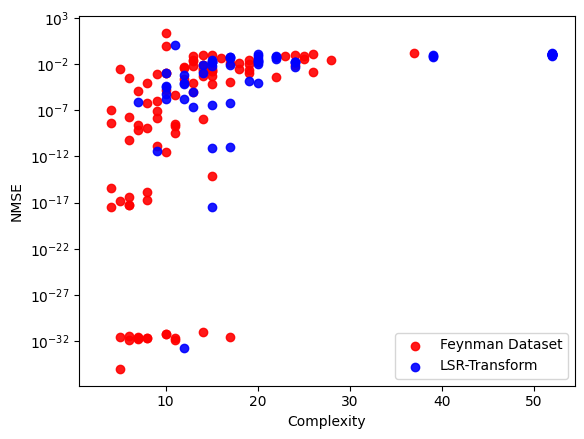

In [18]:
X = np.array(list(complexities.values()))
Y = np.array([metrics[k]['nmse'] for k in complexities.keys()])
plt.scatter(x=X, y=Y, label="Feynman Dataset", color=colors[1], alpha=0.9)

X2 = np.array([transformed_complexities[k] for k in transformed_metrics.keys()])
Y2 = np.array([transformed_metrics[k]['nmse'] for k in transformed_metrics.keys()])
plt.xlabel("Complexity")
plt.ylabel("NMSE")
plt.scatter(x=X2, y=Y2, label="LSR-Transform", color=colors[0], alpha=0.9)
plt.legend()

plt.yscale("log")

In [60]:
# for run_result_csv in run_dirs:
#     df = pd.read_csv(run_result_csv, header = None)
#     df.columns = ['Iteration', 'Complexity', 'Loss', 'Score', 'Expression', 'Time']
#     break


for orig_eq_name in grouped_run_dirs.keys():
    # orig_eq_name = 'I.12.2'
    runs = grouped_run_dirs[orig_eq_name]

    dfs = []
    for i, run_path in enumerate(runs):
        eq_name = os.path.basename(run_path.parent)
        df = pd.read_csv(run_path, header = None)
        df.columns = ['Iteration', 'Complexity', 'Loss', 'Score', 'Expression', 'Time']
        selected_id = df.groupby(by="Iteration")['Loss'].idxmin()
        grouped_df = df.loc[selected_id].copy()
        grouped_df['sympy_format'] = grouped_df['Expression'].apply(lambda s: sympy.sympify(s))

        metrics = defaultdict(list)
        for _, row in grouped_df.iterrows():
            if i == 0:
                test_points = dm.problems[dm.name2id[eq_name]].samples['test'][:2000]
            else:
                test_points = transformed_dm.problems[transformed_dm.name2id[eq_name]].samples['test'][:2000]

            m = compute_metrics(row.Expression.translate(SUB), test_points)
            for k,v in m.items():
                metrics[k].append(v)
        for k,v in metrics.items():
            grouped_df[k] = v
        # compute_metrics(dfs[0].iloc[0].Expression.strip().translate(SUB), dm.problems[dm.name2id[eq_name]].samples['train'])

        dfs.append(grouped_df)
    # break

In [61]:
dfs[0].head()

,Iteration,Complexity,Loss,Score,Expression,Time,sympy_format,mse,nmse,r2,kdt,mape,num_valid_points
13,1,21,385.855600,0.343832,x₁ / (((((x₂ * (sqrt(x₁ + x₂) + sin(x₀))) + 0...,5.487560,x₁/((x₃ + 0.86908)*(x₃*(x₂*(sqrt(x₁ + x₂) + si...,3.956130e-04,0.047294,0.952706,0.881833,0.349130,2000
23,2,21,385.855600,0.343832,x₁ / (((((x₂ * (sqrt(x₁ + x₂) + sin(x₀))) + 0...,6.275567,x₁/((x₃ + 0.86908)*(x₃*(x₂*(sqrt(x₁ + x₂) + si...,3.956130e-04,0.047294,0.952706,0.881833,0.349130,2000
37,3,21,385.855600,0.343832,x₁ / (((((x₂ * (sqrt(x₁ + x₂) + sin(x₀))) + 0...,6.871316,x₁/((x₃ + 0.86908)*(x₃*(x₂*(sqrt(x₁ + x₂) + si...,3.956130e-04,0.047294,0.952706,0.881833,0.349130,2000
51,4,21,385.855600,0.343832,x₁ / (((((x₂ * (sqrt(x₁ + x₂) + sin(x₀))) + 0...,6.907520,x₁/((x₃ + 0.86908)*(x₃*(x₂*(sqrt(x₁ + x₂) + si...,3.956130e-04,0.047294,0.952706,0.881833,0.349130,2000
67,5,26,0.452959,6.150990,((((sqrt(1.0144 ^ ((x₃ - -0.31483) + -1.4304)...,7.599929,0.0789257795473059*x₀*x₁*sqrt(1.0144**(x₃ - 1....,5.984246e-07,0.000072,0.999928,0.996841,0.008213,2000


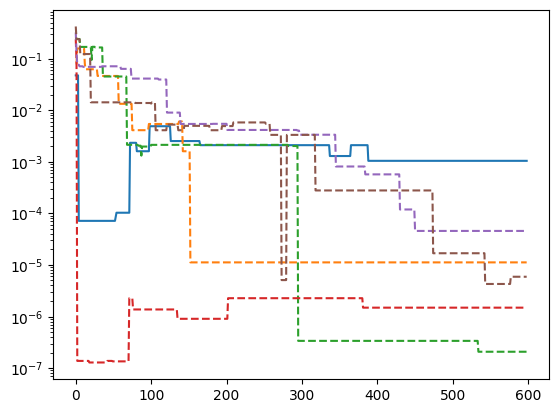

In [64]:
metric_name = 'nmse'
plt.plot(dfs[0][metric_name].values, linestyle='-')
for i, s in enumerate(dfs[1:]):
    plt.plot(s[metric_name].values, linestyle='--')
plt.yscale("log")